# Marketing campaign analytics toy case

Goal of this project: Create a deployment rule that maximizes net return on the marketing campaign.

The marketing campaign consist in an email that a customer receives.

We want to evaluate if we can bring an incremental value by using Double ML and T-Learner.

## 0. Import libraries and load dfs

In [82]:
import pandas as pd
import numpy as np
import os

#data viz
import matplotlib.pyplot as plt
import seaborn as sns

#Nuisance Parameter Estimation
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict

#file_path = 'https://github.com/andresvourakis/synthetic-e-commerce-data-with-marketing-campaign/raw/refs/heads/main/sales_data_with_marketing_intervention.csv'
#df = pd.read_csv(file_path, on_bad_lines='skip')

In [7]:
file_path_1='.\data\email_obs_data.csv' #historical data
file_path_2='.\data\email_rnd_data.csv' #experiment when mkt_email is randomized
df1 = pd.read_csv(file_path_1)
df2 = pd.read_csv(file_path_2)

## 1. EDA

In [8]:
df1.head()

,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,34.38,32.0,0.0,18.05,0,0,1,1,1,...,3,0,1,0,1,2,2,0,1,1
1,0,183.14,23.0,1.0,182.97,0,0,0,1,0,...,1,1,0,0,0,2,2,1,2,1
2,0,54.26,29.0,0.0,29.57,0,0,0,1,4,...,3,0,0,0,3,0,0,0,1,4
3,1,1409.71,44.0,0.0,142.15,1,2,0,1,0,...,1,0,1,1,1,3,0,1,0,5
4,0,120.16,30.0,0.0,132.11,0,1,1,0,1,...,1,2,1,1,2,3,0,0,2,5


In [9]:
df2.head()

,mkt_email,next_mnth_pv,age,tenure,ammount_spent,vehicle,food,beverage,art,baby,...,electronics,sports,tools,games,industry,pc,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,21.84,0,2,2,0,2,...,1,0,0,3,1,0,1,0,0,2
1,0,29.67,36.0,1.0,107.40,0,2,0,2,0,...,1,1,1,2,1,2,1,0,2,2
2,0,11.73,64.0,0.0,59.81,0,1,0,0,0,...,2,0,0,3,0,1,0,1,0,1
3,0,41.41,74.0,0.0,62.98,0,1,0,0,3,...,1,0,2,2,1,1,0,4,1,0
4,0,447.89,59.0,0.0,72.56,0,1,1,3,2,...,5,0,0,1,0,0,1,1,2,1


In [11]:
print("df1 has " + str(len(df1)) + " rows.")
print("df2 has " + str(len(df2)) + " rows.")

df1 has 300000 rows.
df2 has 10000 rows.


### 1.1 Defining target variables and columns

In [20]:
# T = mkt_email (Treatment)
# Y = next_mnth_pv (Outcome)
# X = age, income, insurance, investing, etc. (Covariates)
T_col = 'mkt_email'
Y_col = 'next_mnth_pv'
X_cols = [col for col in df1.columns if col not in [T_col, Y_col]]

print(f"Features (X): {X_cols}\n")

Features (X): ['age', 'tenure', 'ammount_spent', 'vehicle', 'food', 'beverage', 'art', 'baby', 'personal_care', 'toys', 'clothing', 'decor', 'cell_phones', 'construction', 'home_appliances', 'electronics', 'sports', 'tools', 'games', 'industry', 'pc', 'jewel', 'books', 'music_books_movies', 'health']



### 1.2 Analyze selection bias and confounding factors

In [23]:
print("--- Mean Covariates by Treatment Group ---")
print("\n[Observational Data (df1)] - Expecting discrepancies (Bias):")
print(df1.groupby(T_col)[X_cols].mean().T)

print("\n[Randomized Data (df2)] - Expecting balance (No Bias):")
print(df2.groupby(T_col)[X_cols].mean().T)

--- Mean Covariates by Treatment Group ---

[Observational Data (df1)] - Expecting discrepancies (Bias):
mkt_email                    0           1
age                  38.042110   37.947912
tenure                0.418509    0.433552
ammount_spent       101.534675  593.019466
vehicle               0.100737    0.100985
food                  0.998051    1.002447
beverage              0.994658    0.999002
art                   1.004218    0.995523
baby                  1.005288    0.998532
personal_care         0.999250    0.999093
toys                  0.994481    1.002140
clothing              1.995278    2.006519
decor                 0.999319    0.999798
cell_phones           2.997642    2.999752
construction          1.001554    1.004039
home_appliances       1.001049    0.999276
electronics           1.997724    2.001416
sports                1.001356    1.000444
tools                 0.999332    1.006715
games                 2.000763    1.999419
industry              1.000593    0

C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

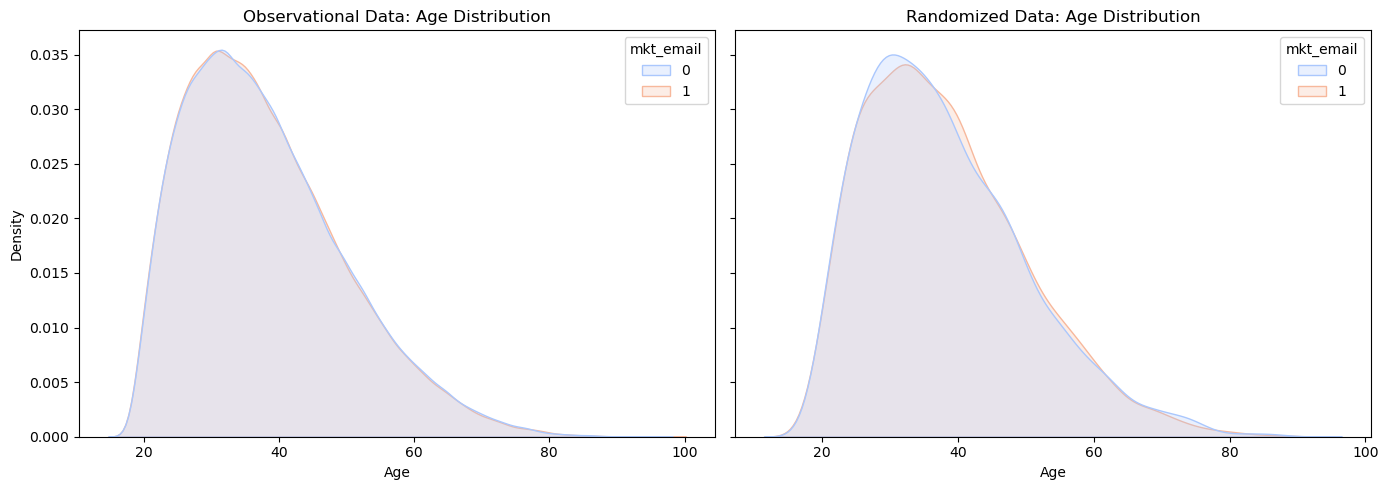

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
# Plot for Observational Data
sns.kdeplot(data=df1, x='age', hue=T_col, common_norm=False, fill=True, ax=axes[0], palette='coolwarm')
axes[0].set_title('Observational Data: Age Distribution')
axes[0].set_xlabel('Age')

# Plot for Randomized Data
sns.kdeplot(data=df2, x='age', hue=T_col, common_norm=False, fill=True, ax=axes[1], palette='coolwarm')
axes[1].set_title('Randomized Data: Age Distribution')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\grego\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

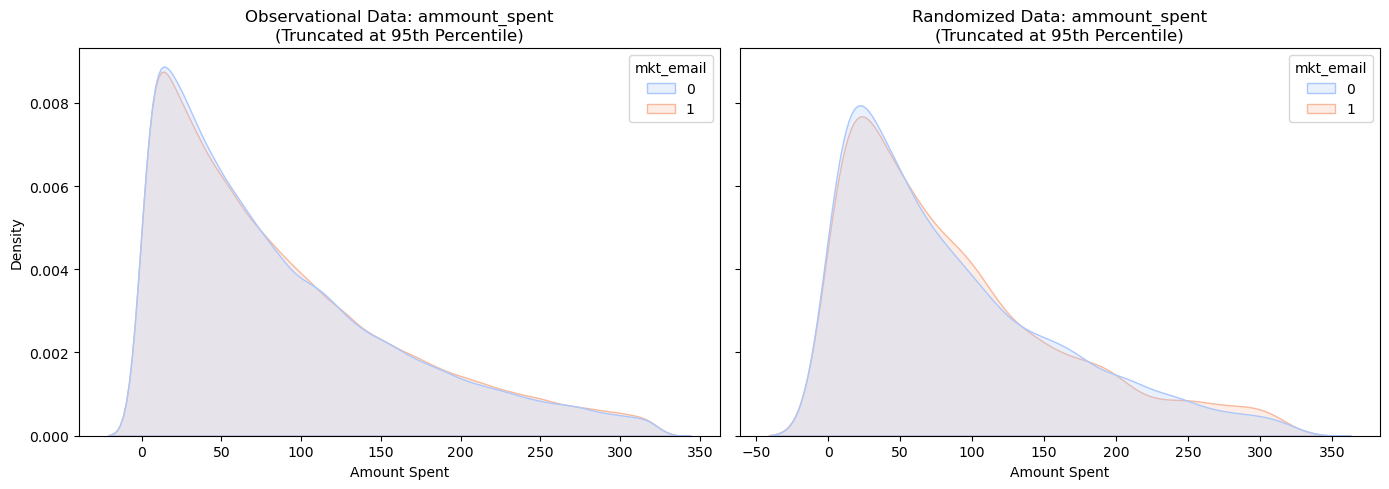

In [42]:
#additional analysis on ammount spent
var_col = 'ammount_spent' 

#calculating the 95th percentile threshold from the observational data to clip the long tail
upper_limit = df1[var_col].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1. Plot for Observational Data (Truncated)
sns.kdeplot(
    data=df1[df1[var_col] <= upper_limit], 
    x=var_col, 
    hue=T_col, 
    common_norm=False, 
    fill=True, 
    ax=axes[0], 
    palette='coolwarm'
)
axes[0].set_title(f'Observational Data: {var_col}\n(Truncated at 95th Percentile)')
axes[0].set_xlabel('Amount Spent')

# 2. Plot for Randomized Data (Truncated using the same upper limit for direct comparison)
sns.kdeplot(
    data=df2[df2[var_col] <= upper_limit], 
    x=var_col, 
    hue=T_col, 
    common_norm=False, 
    fill=True, 
    ax=axes[1], 
    palette='coolwarm'
)
axes[1].set_title(f'Randomized Data: {var_col}\n(Truncated at 95th Percentile)')
axes[1].set_xlabel('Amount Spent')

plt.tight_layout()
plt.show()

## 2.Nuisance Parameter Estimation
Objective: Model the baseline outcomes and treatment assignment mechanisms to isolate the causal effect.

In [58]:
random_state_var=43 #42 is not always the answer...

### 2.1 Selecting the best model for propensity scores

In [64]:
#Define candidates
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state_var),
    'Random Forest': RandomForestClassifier(max_depth=5, n_estimators=100, random_state=random_state_var),
    'XGBoost': XGBClassifier(max_depth=3, n_estimators=100, learning_rate=0.05, eval_metric='logloss', random_state=random_state_var)
}

#Setup Stratified K-Fold for classification evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state_var)
results = []

#valuate each model
for name, model in models.items():
    oo_preds = np.zeros(len(df1))
    
    for train_idx, val_idx in cv.split(X, T):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        t_train, t_val = T.iloc[train_idx], T.iloc[val_idx]
        
        model.fit(X_train, t_train)
        oo_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    
    # Calculate evaluation metrics
    auc = roc_auc_score(T, oo_preds)
    brier = brier_score_loss(T, oo_preds)
    
    # Check for extreme values (positivity violations)
    near_0_or_1 = np.sum((oo_preds < 0.01) | (oo_preds > 0.99)) / len(oo_preds)
    
    results.append({
        'Model': name,
        'ROC-AUC (Higher = More Predictive)': auc,
        'Brier Score (Lower = Better Calibrated)': brier,
        '% Extreme Propensities (<1% or >99%)': near_0_or_1
    })

#Display comparison table
perf_df = pd.DataFrame(results)
print(perf_df.to_string(index=False))

              Model  ROC-AUC (Higher = More Predictive)  Brier Score (Lower = Better Calibrated)  % Extreme Propensities (<1% or >99%)
Logistic Regression                            0.518651                                 0.247645                              0.007383
      Random Forest                            0.517926                                 0.247928                              0.000000
            XGBoost                            0.518845                                 0.247745                              0.007517


<b>Analysis of Results</b>

All three models show an ROC-AUC of 0.52. This indicates that our observed features ($X$) have virtually no predictive power over who receives the marketing email ($T$). 
The observational dataset already behaves similarly to a randomized experiment regarding these specific variables, meaning selection bias is low.

<b>Calibration:</b> The Brier scores are tightly clustered around 0.247, which is right next to the 0.25 baseline of a random 50-50 guess. The probabilities are stable and well-calibrated across the board.

<b>Positivity/Overlap:</b> Random Forest yields exactly 0% extreme propensities, completely eliminating the risk of variance inflation downstream. 
Logistic Regression and XGBoost introduce a tiny amount of edge-case risk (~0.7%).

<b>Final decision:</b> I'll go with the Random Forest for our propensity score model. It captures the same minimal baseline signal as the other architectures while guaranteeing perfect covariate overlap.

### 2.2 Implementing the best model

In [81]:
#Define inputs
X = df1[X_cols]
T = df1[T_col]
Y = df1[Y_col]

#Initialize Random Forest models for both parameters
ps_model = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=random_state_var, n_jobs=-1)
y_model = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=random_state_var, n_jobs=-1)

#Setup Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("Estimating nuisance parameters using Random Forest via 5-fold cross-validation...")

#Out-of-fold Propensity Scores: e(X)
df1['ps'] = cross_val_predict(ps_model, X, T, cv=cv, method='predict_proba')[:, 1]

#Out-of-fold Outcome Predictions: m(X)
df1['y_hat'] = cross_val_predict(y_model, X, Y, cv=cv)

#Calculate Residuals (for DML)
df1['t_res'] = df1[T_col] - df1['ps']
df1['y_res'] = df1[Y_col] - df1['y_hat']

print("Nuisance parameter estimation complete. Columns 'ps', 'y_hat', 't_res', and 'y_res' added.")

Estimating nuisance parameters using Random Forest via 5-fold cross-validation...
Nuisance parameter estimation complete. Columns 'ps', 'y_hat', 't_res', and 'y_res' added.


## 3. CATE Estimation via Metalearners
Estimate the Conditional Average Treatment Effect (CATE) for each customer profile.

### 3.1 Implement T-Learner

In [98]:
print("Training T-Learner...")
m0 = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=random_state_var, n_jobs=-1)
m1 = RandomForestRegressor(max_depth=5, n_estimators=100, random_state=random_state_var, n_jobs=-1)

# Train base models on control (T=0) and treated (T=1) subsets separately
m0.fit(X[T == 0], Y[T == 0])
m1.fit(X[T == 1], Y[T == 1])

# Estimate CATE: mu_1(X) - mu_0(X)
df1['cate_t_learner'] = m1.predict(X) - m0.predict(X)

Training T-Learner...


### 3.2 Implement Double ML

In [99]:
print("Training Double Machine Learning (DML)...")
# We interact the treatment residuals with the features X to capture effect heterogeneity:
# Y_res = tau(X) * T_res -> Y_res = (beta_0 + beta_1*X_1 + ... + beta_n*X_n) * T_res
X_dml = X.multiply(df1['t_res'], axis=0)
X_dml['t_res'] = df1['t_res']  # Include the main effect of the treatment residual

dml_effect_model = LinearRegression(fit_intercept=False)
dml_effect_model.fit(X_dml, df1['y_res'])

# Extract the coefficients to compute personalized CATE for each row
coefficients = dml_effect_model.coef_[:-1]  # interaction terms
intercept_effect = dml_effect_model.coef_[-1]  # main treatment effect

df1['cate_dml'] = np.dot(X, coefficients) + intercept_effect

Training Double Machine Learning (DML)...


### 3.3 Inspect CATE distributions

In [100]:
print("\nCATE Estimation complete.")
print(df1[['cate_t_learner', 'cate_dml']].describe())


CATE Estimation complete.
       cate_t_learner       cate_dml
count   300000.000000  300000.000000
mean      1379.906527    1306.998853
std        854.338970     294.187081
min      -6104.553387    -606.081616
25%       1172.831921    1108.353324
50%       1320.291887    1298.062181
75%       1407.584083    1498.064170
max      63954.405589    2812.352896


## 4. Unbiased Model Evaluation
Validate the metalearner predictions using the randomized experiment data.

### 4.1 Predict CATE on the randomized dataset (df2)

In [107]:
df2['cate_t_learner'] = m1.predict(df2[X_cols]) - m0.predict(df2[X_cols])
df2['cate_dml'] = np.dot(df2[X_cols], coefficients) + intercept_effect

### 4.2 Function to compute and plot the Cumulative Gain (Uplift) Curve

In [110]:
def plot_cumulative_gain(df, prediction_col, ax, title):
    # Sort descending by predicted elasticity
    df_sorted = df.sort_values(by=prediction_col, ascending=False).reset_index(drop=True)
    
    # Cumulative counts of treated and control groups
    n_treated = df_sorted[T_col].cumsum()
    n_control = (1 - df_sorted[T_col]).cumsum()
    
    # Cumulative outcomes
    cum_y_treated = (df_sorted[Y_col] * df_sorted[T_col]).cumsum()
    cum_y_control = (df_sorted[Y_col] * (1 - df_sorted[T_col])).cumsum()
    
    # Compute cumulative uplift: (Mean Y_treated - Mean Y_control) * Current Population Size
    mean_y_t = cum_y_treated / n_treated.replace(0, np.nan)
    mean_y_c = cum_y_control / n_control.replace(0, np.nan)
    
    cumulative_gain = (mean_y_t - mean_y_c) * (n_treated + n_control)
    cumulative_gain = cumulative_gain.fillna(0)
    
    # Baseline (Random assignment strategy)
    random_baseline = np.linspace(0, cumulative_gain.iloc[-1], len(df_sorted))
    
    # Plotting
    ax.plot(cumulative_gain.values, label='Model Strategy', color='blue')
    ax.plot(random_baseline, linestyle='--', color='gray', label='Random Strategy')
    ax.set_title(title)
    ax.set_xlabel('Population Sorted by Predicted Uplift')
    ax.set_ylabel('Cumulative Gain (Revenue / Value)')
    ax.legend()

### 4.3 Execute Evaluation Plot

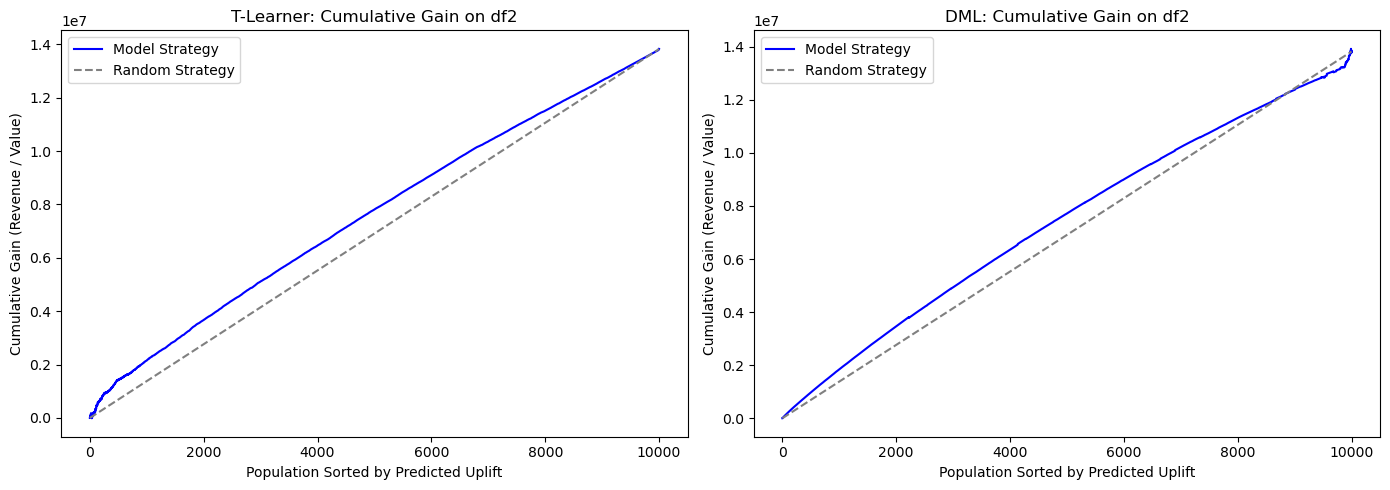

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_cumulative_gain(df2, 'cate_t_learner', axes[0], 'T-Learner: Cumulative Gain on df2')
plot_cumulative_gain(df2, 'cate_dml', axes[1], 'DML: Cumulative Gain on df2')

plt.tight_layout()
plt.show()

## 5. Optimal Policy Design & ROI Simulation
Create a deployment rule that maximizes net return on the marketing campaign.

### 5.1 Define the business constraint (Cost per email)

In [118]:
# Assume sending an email costs 1.5 units of whatever currency Y is measured in
UNIT_COST = 1.5

### 5.2 Define the Targeting Policy

In [121]:
# Rule: Send email (Target = 1) ONLY if predicted CATE is greater than the cost
df2['target_t_learner'] = (df2['cate_t_learner'] > UNIT_COST).astype(int)
df2['target_dml'] = (df2['cate_dml'] > UNIT_COST).astype(int)

### 5.3 Policy Evaluation on Randomized Data (Unbiased Counterfactual Estimation)

In [124]:
def evaluate_policy_roi(df, target_col, cost):
    """
    Evaluates a policy using randomized data by looking at the subgroup 
    where the random assignment matches the policy's recommendation.
    """
    # Filter for rows where random assignment (T_col) matches the policy recommendation
    matched_data = df[df[T_col] == df[target_col]]
    
    # Calculate average revenue for the strategy
    avg_revenue = matched_data[Y_col].mean()
    
    # Calculate average cost: cost is only incurred if the policy decides to target
    avg_cost = df[target_col].mean() * cost
    
    # Net Value = Revenue - Cost
    net_value = avg_revenue - avg_cost
    return net_value, df[target_col].mean()

### 5.4 Calculate ROI for Baseline Strategies
Baseline Strategies are basically send the email to no customer or send the email to all customers

In [128]:
# Strategy A: Send to nobody (Target = 0 for all)
df2['target_none'] = 0
val_none, pct_none = evaluate_policy_roi(df2, 'target_none', UNIT_COST)

# Strategy B: Send to everybody (Target = 1 for all)
df2['target_all'] = 1
val_all, pct_all = evaluate_policy_roi(df2, 'target_all', UNIT_COST)

### 5.5 Calculate ROI for Random Forest-Driven Strategies

In [131]:
val_tl, pct_tl = evaluate_policy_roi(df2, 'target_t_learner', UNIT_COST)
val_dml, pct_dml = evaluate_policy_roi(df2, 'target_dml', UNIT_COST)

### 5.6 Summary Comparison Table

In [134]:
roi_results = pd.DataFrame({
    'Targeting Strategy': ['Send to None', 'Send to All', 'T-Learner Policy', 'DML Policy'],
    '% Population Targeted': [f"{pct_none*100:.1f}%", f"{pct_all*100:.1f}%", f"{pct_tl*100:.1f}%", f"{pct_dml*100:.1f}%"],
    'Expected Net Value per User': [val_none, val_all, val_tl, val_dml]
})

print("--- Final Policy Optimization & ROI Simulation ---")
print(roi_results.to_string(index=False))

# Calculate absolute financial lift of the best model vs sending to everyone
best_value = max(val_tl, val_dml)
lift_vs_all = (best_value - val_all) * len(df2)
print(f"\nTotal estimated budget optimization lift vs 'Send to All' strategy: {lift_vs_all:,.2f}")

--- Final Policy Optimization & ROI Simulation ---
Targeting Strategy % Population Targeted  Expected Net Value per User
      Send to None                  0.0%                   152.980824
       Send to All                100.0%                  1533.570622
  T-Learner Policy                100.0%                  1534.397716
        DML Policy                100.0%                  1528.224401

Total estimated budget optimization lift vs 'Send to All' strategy: 8,270.94
